# Pixel-Level Contrastive U-Net (Joint, Loss-Checkpointed)

This notebook uses joint segmentation + pixel-level contrastive training with a stronger segmentation head.

Key behavior in this version:
1. Only the joint model is trained/evaluated/exported.
2. Non-tumour batches are not skipped: segmentation loss is always applied, while contrastive loss contributes when valid positive pairs exist.
3. Contrastive loss is down-weighted (`0.1`) to act as regularization.
4. Best checkpoint selection is based on **validation loss**; threshold sweep is run once at the end of training.

In [1]:
   # PyTorch install notes for Tesla P100 (sm_60):
# - On Python 3.12, current official CUDA wheels usually do not include sm_60 kernels.
# - If this notebook is on Kaggle Python 3.12, prefer CPU fallback or switch accelerator to T4/V100.
# - If you control the environment, use Python 3.10/3.11 + CUDA 11.8 wheels, e.g.:
#   pip install torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2 --index-url https://download.pytorch.org/whl/cu118

# Keep this for environments where compatible wheels exist:
%pip uninstall -y torch torchvision torchaudio
%pip install --no-cache-dir torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 338.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 111.9 MB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 352.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 372.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 397.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Optional sanity check: run after kernel restart.
import torch

print('torch version:', torch.__version__)
print('cuda available:', torch.cuda.is_available())

if torch.cuda.is_available():
    try:
        print('cuda device:', torch.cuda.get_device_name(0))
        print('capability:', torch.cuda.get_device_capability(0))
        if hasattr(torch.cuda, 'get_arch_list'):
            print('torch cuda arch list:', torch.cuda.get_arch_list())
        _ = torch.randn(1, device='cuda') * 2.0
        torch.cuda.synchronize()
        print('CUDA test op: OK')
    except RuntimeError as e:
        msg = str(e).lower()
        if 'no kernel image is available for execution on the device' in msg or 'cudaerrornokernelimagefordevice' in msg:
            print('This PyTorch build does not include sm_60 kernels for Tesla P100. Use CPU or a Python 3.10/3.11 + cu118 environment.')
        else:
            raise

torch version: 2.5.1+cu121
cuda available: True
cuda device: Tesla P100-PCIE-16GB
capability: (6, 0)
torch cuda arch list: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
CUDA test op: OK


In [3]:
import json
import os
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


def pick_device() -> torch.device:
    if not torch.cuda.is_available():
        return torch.device('cpu')
    try:
        # Run a tiny CUDA op to catch incompatible binary/architecture issues early.
        _ = torch.randn(1, device='cuda') * 2.0
        torch.cuda.synchronize()
        return torch.device('cuda')
    except RuntimeError as e:
        msg = str(e).lower()
        if 'no kernel image is available for execution on the device' in msg or 'cudaerrornokernelimagefordevice' in msg:
            print('CUDA is available but incompatible with this PyTorch build on this GPU. Falling back to CPU.')
            return torch.device('cpu')
        raise


device = pick_device()
print(f'Using device: {device}')

Using device: cuda


In [4]:
# Detect Kaggle environment automatically; fall back to local workspace path.
_kaggle_data = '/kaggle/input/datasets/sharadprakash117/lung-tumour-baseline-u-net-seg-dataset-filtered/npy_filtered'
_local_data  = os.path.join(os.path.dirname(os.path.abspath('.')), 'npy_filtered')
root_data_dir = _kaggle_data if os.path.exists('/kaggle/input') else _local_data
train_dir = os.path.join(root_data_dir, 'train')
val_dir = os.path.join(root_data_dir, 'val')
test_dir = os.path.join(root_data_dir, 'test')

joint_epochs = 25
batch_size = 8
learning_rate_joint = 5e-4
threshold_metric = 'dice'
contrastive_temperature = 0.2
joint_segmentation_weight = 1.0
joint_contrastive_weight = 0.1
max_positive_samples = None
negative_ratio = 2.0
max_negative_samples = None
boundary_kernel_size = 5
boundary_fraction = 0.75
num_workers = 0
joint_loss_name = 'tversky'

output_dir = os.path.join(os.getcwd(), 'contrastive_outputs_joint_loss_ckpt')
checkpoint_dir = os.path.join(output_dir, 'checkpoints')
os.makedirs(checkpoint_dir, exist_ok=True)

print('root_data_dir =', root_data_dir)
print('checkpoint_dir =', checkpoint_dir)

root_data_dir = /kaggle/input/datasets/sharadprakash117/lung-tumour-baseline-u-net-seg-dataset-filtered/npy_filtered
checkpoint_dir = /kaggle/working/contrastive_outputs_joint_loss_ckpt/checkpoints


In [5]:
class NpyLesionDataset(Dataset):
    def __init__(self, root_dir: str, transform: Optional[A.Compose] = None):
        self.root_dir = root_dir
        self.transform = transform
        self.file_pairs: List[Dict[str, str]] = []

        for dir_name in sorted(os.listdir(root_dir)):
            data_dir = os.path.join(root_dir, dir_name, 'data')
            masks_dir = os.path.join(root_dir, dir_name, 'masks')
            if not os.path.isdir(data_dir):
                continue

            for fname in sorted(os.listdir(data_dir)):
                if fname.endswith('.npy'):
                    self.file_pairs.append(
                        {
                            'image': os.path.join(data_dir, fname),
                            'mask': os.path.join(masks_dir, fname),
                        }
                    )

    def __len__(self) -> int:
        return len(self.file_pairs)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        pair = self.file_pairs[idx]
        image = np.load(pair['image']).astype(np.float32)
        mask = np.load(pair['mask']).astype(np.float32)
        mask = (mask > 0).astype(np.float32)

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)
        return torch.from_numpy(image), torch.from_numpy(mask)


train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ElasticTransform(alpha=40.0, sigma=5.0, p=0.35),
    ]
)
val_test_transform = A.Compose([])

train_dataset = NpyLesionDataset(train_dir, transform=train_transform)
val_dataset = NpyLesionDataset(val_dir, transform=val_test_transform)
test_dataset = NpyLesionDataset(test_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Train: 2868 | Val: 148 | Test: 1335


In [6]:
class BCEDiceLoss(nn.Module):
    def __init__(self, alpha: float = 0.5, smooth: float = 1e-6):
        super().__init__()
        self.alpha = alpha
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits).reshape(-1)
        targets_f = targets.reshape(-1)

        intersection = (probs * targets_f).sum()
        dice_coeff = (2.0 * intersection + self.smooth) / (probs.sum() + targets_f.sum() + self.smooth)
        dice_loss = 1.0 - dice_coeff
        return self.alpha * bce_loss + (1.0 - self.alpha) * dice_loss


class TverskyLoss(nn.Module):
    def __init__(self, alpha: float = 0.3, beta: float = 0.7, smooth: float = 1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits).reshape(-1)
        targets_f = targets.reshape(-1)

        tp = (probs * targets_f).sum()
        fp = ((1.0 - targets_f) * probs).sum()
        fn = (targets_f * (1.0 - probs)).sum()
        tversky = (tp + self.smooth) / (tp + self.alpha * fn + self.beta * fp + self.smooth)
        return 1.0 - tversky


def build_phase2_loss(loss_name: str = 'tversky') -> nn.Module:
    loss_name = loss_name.lower()
    if loss_name == 'tversky':
        return TverskyLoss(alpha=0.3, beta=0.7)
    if loss_name == 'bce_dice':
        return BCEDiceLoss(alpha=0.5)
    raise ValueError(f'Unsupported loss_name: {loss_name}')

## Contrastive U-Net Architecture

The feature extractor ends in a dense 64-channel map at full image resolution. This notebook uses a stronger segmentation head (Conv-BN-ReLU-Dropout-Conv) instead of a single 1x1 convolution.

Training is **joint only**: segmentation and contrastive losses are optimized together in one regime.

In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.double_conv(x)


class ProjectionHead(nn.Module):
    def __init__(self, in_channels: int = 64, embedding_dim: int = 128, hidden_channels: int = 128):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, embedding_dim, kernel_size=1, bias=True),
        )

    def forward(self, feature_map: torch.Tensor) -> torch.Tensor:
        return self.layers(feature_map)


class ClassificationHead(nn.Module):
    def __init__(self, in_channels: int = 64, hidden_channels: int = 64, out_channels: int = 1, dropout_p: float = 0.15):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p),
            nn.Conv2d(hidden_channels, out_channels, kernel_size=1, bias=True),
        )

    def forward(self, feature_map: torch.Tensor) -> torch.Tensor:
        return self.classifier(feature_map)


class UNetContrastive(nn.Module):
    def __init__(self, in_channels: int = 1, feature_channels: int = 64, embedding_dim: int = 128):
        super().__init__()
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))

        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(256, 128)

        self.up3 = nn.ConvTranspose2d(128, feature_channels, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(128, feature_channels)

        self.projection_head = ProjectionHead(in_channels=feature_channels, embedding_dim=embedding_dim)
        self.classification_head = ClassificationHead(in_channels=feature_channels, hidden_channels=feature_channels, out_channels=1)

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x = self.up1(x4)
        x = torch.cat([x3, x], dim=1)
        x = self.conv_up1(x)

        x = self.up2(x)
        x = torch.cat([x2, x], dim=1)
        x = self.conv_up2(x)

        x = self.up3(x)
        x = torch.cat([x1, x], dim=1)
        x = self.conv_up3(x)
        return x

    def forward_projection(self, features: torch.Tensor) -> torch.Tensor:
        return self.projection_head(features)

    def forward_classification(self, features: torch.Tensor) -> torch.Tensor:
        return self.classification_head(features)

    def forward(self, x: torch.Tensor, mode: str = 'classification') -> torch.Tensor:
        features = self.forward_features(x)
        mode = mode.lower()
        if mode == 'features':
            return features
        if mode == 'projection':
            return self.forward_projection(features)
        if mode == 'classification':
            return self.forward_classification(features)
        raise ValueError(f'Unsupported mode: {mode}')


model = UNetContrastive().to(device)
print(model.__class__.__name__)

UNetContrastive


## Pixel Sampling for Contrastive Learning

The sampler keeps memory use under control by only gathering a small subset of pixel embeddings per image. Positive samples come from lesion pixels. Negative samples are chosen from a boundary ring around the lesion first, then filled from the remaining background when needed.

In [8]:
@dataclass
class PixelSampleBatch:
    positive_embeddings: torch.Tensor
    negative_embeddings: torch.Tensor
    positive_image_ids: torch.Tensor
    negative_image_ids: torch.Tensor
    positive_counts: List[int]
    negative_counts: List[int]
    boundary_negative_counts: List[int]
    skipped_images: List[int]


def _sample_indices(indices: torch.Tensor, max_samples: Optional[int]) -> torch.Tensor:
    if indices.numel() == 0:
        return indices
    if max_samples is None or indices.numel() <= max_samples:
        return indices
    perm = torch.randperm(indices.numel(), device=indices.device)[:max_samples]
    return indices[perm]


def _compute_boundary_mask(mask: torch.Tensor, kernel_size: int = 5) -> torch.Tensor:
    if kernel_size % 2 == 0:
        raise ValueError('kernel_size must be odd so the boundary ring is symmetric.')
    if mask.ndim != 4 or mask.size(1) != 1:
        raise ValueError('mask must have shape (B, 1, H, W).')

    mask_float = mask.float()
    dilated = F.max_pool2d(mask_float, kernel_size=kernel_size, stride=1, padding=kernel_size // 2)
    boundary = (dilated > 0.0) & (mask_float < 0.5)
    return boundary


def compute_negative_sampling_mask(
    images: torch.Tensor,
    threshold_ratio: float = 0.03,
    dilation_kernel_size: int = 11,
) -> torch.Tensor:
    if images.ndim != 4 or images.size(1) != 1:
        raise ValueError('images must have shape (B, 1, H, W).')
    if dilation_kernel_size % 2 == 0:
        raise ValueError('dilation_kernel_size must be odd.')

    images_f = images.float()
    img_min = images_f.amin(dim=(2, 3), keepdim=True)
    img_max = images_f.amax(dim=(2, 3), keepdim=True)
    img_norm = (images_f - img_min) / (img_max - img_min + 1e-6)
    coarse_foreground = img_norm > threshold_ratio

    try:
        from scipy import ndimage as ndi  # type: ignore
    except Exception:
        # Fallback when scipy is unavailable: keep simple dilated non-air mask.
        return F.max_pool2d(
            coarse_foreground.float(),
            kernel_size=dilation_kernel_size,
            stride=1,
            padding=dilation_kernel_size // 2,
        ) > 0.0

    refined_masks = []
    for b in range(coarse_foreground.size(0)):
        fg_np = coarse_foreground[b, 0].detach().cpu().numpy().astype(np.uint8)

        opened = ndi.binary_opening(fg_np, structure=np.ones((3, 3), dtype=np.uint8))
        closed = ndi.binary_closing(opened, structure=np.ones((5, 5), dtype=np.uint8))

        labeled, num_components = ndi.label(closed)
        if num_components > 0:
            counts = np.bincount(labeled.ravel())
            counts[0] = 0
            largest_component = labeled == int(np.argmax(counts))
        else:
            largest_component = closed

        filled = ndi.binary_fill_holes(largest_component)
        dilated = ndi.binary_dilation(
            filled,
            structure=np.ones((dilation_kernel_size, dilation_kernel_size), dtype=np.uint8),
        )
        refined_masks.append(torch.from_numpy(dilated.astype(np.float32)))

    refined_tensor = torch.stack(refined_masks, dim=0).unsqueeze(1).to(images.device)
    return refined_tensor > 0.5


def sample_pixel_embeddings(
    projected_embeddings: torch.Tensor,
    masks: torch.Tensor,
    max_positive_samples: Optional[int] = None,
    negative_ratio: float = 2.0,
    max_negative_samples: Optional[int] = None,
    boundary_kernel_size: int = 5,
    boundary_fraction: float = 0.75,
    negative_sampling_mask: Optional[torch.Tensor] = None,
) -> PixelSampleBatch:
    if projected_embeddings.ndim != 4:
        raise ValueError('projected_embeddings must have shape (B, C, H, W).')
    if masks.ndim != 4 or masks.size(1) != 1:
        raise ValueError('masks must have shape (B, 1, H, W).')
    if projected_embeddings.shape[0] != masks.shape[0] or projected_embeddings.shape[2:] != masks.shape[2:]:
        raise ValueError('Embeddings and masks must share batch and spatial dimensions.')
    if negative_sampling_mask is not None:
        if negative_sampling_mask.ndim != 4 or negative_sampling_mask.size(1) != 1:
            raise ValueError('negative_sampling_mask must have shape (B, 1, H, W).')
        if negative_sampling_mask.shape[0] != masks.shape[0] or negative_sampling_mask.shape[2:] != masks.shape[2:]:
            raise ValueError('negative_sampling_mask must match mask batch and spatial dimensions.')

    boundary_masks = _compute_boundary_mask(masks, kernel_size=boundary_kernel_size)
    flattened_embeddings = projected_embeddings.permute(0, 2, 3, 1).reshape(projected_embeddings.size(0), -1, projected_embeddings.size(1))
    flattened_masks = masks.reshape(masks.size(0), -1) > 0.5
    flattened_boundaries = boundary_masks.reshape(boundary_masks.size(0), -1)
    flattened_sampling_mask = None if negative_sampling_mask is None else (negative_sampling_mask.reshape(negative_sampling_mask.size(0), -1) > 0.5)

    pos_embeddings_list: List[torch.Tensor] = []
    neg_embeddings_list: List[torch.Tensor] = []
    pos_image_ids: List[torch.Tensor] = []
    neg_image_ids: List[torch.Tensor] = []
    positive_counts: List[int] = []
    negative_counts: List[int] = []
    boundary_negative_counts: List[int] = []
    skipped_images: List[int] = []

    for image_idx in range(projected_embeddings.size(0)):
        embeddings_i = flattened_embeddings[image_idx]
        positive_indices = torch.nonzero(flattened_masks[image_idx], as_tuple=False).squeeze(1)
        if positive_indices.numel() == 0:
            skipped_images.append(image_idx)
            positive_counts.append(0)
            negative_counts.append(0)
            boundary_negative_counts.append(0)
            continue

        positive_indices = _sample_indices(positive_indices, max_positive_samples)
        sampled_positive_embeddings = embeddings_i.index_select(0, positive_indices)

        target_negative_count = max_negative_samples
        if target_negative_count is None:
            target_negative_count = max(1, int(np.ceil(positive_indices.numel() * negative_ratio)))

        if flattened_sampling_mask is None:
            boundary_candidate_mask = flattened_boundaries[image_idx]
            background_candidate_mask = ~flattened_masks[image_idx]
        else:
            boundary_candidate_mask = flattened_boundaries[image_idx] & flattened_sampling_mask[image_idx]
            background_candidate_mask = (~flattened_masks[image_idx]) & flattened_sampling_mask[image_idx]

        boundary_indices = torch.nonzero(boundary_candidate_mask, as_tuple=False).squeeze(1)
        if boundary_indices.numel() == 0:
            boundary_indices = torch.nonzero(flattened_boundaries[image_idx], as_tuple=False).squeeze(1)

        background_indices = torch.nonzero(background_candidate_mask, as_tuple=False).squeeze(1)
        if background_indices.numel() == 0:
            background_indices = torch.nonzero(~flattened_masks[image_idx], as_tuple=False).squeeze(1)

        max_boundary = min(boundary_indices.numel(), int(np.ceil(target_negative_count * boundary_fraction)))
        sampled_boundary_indices = _sample_indices(boundary_indices, max_boundary)

        remaining_negative_count = max(0, target_negative_count - sampled_boundary_indices.numel())
        if sampled_boundary_indices.numel() > 0:
            keep_background = ~torch.isin(background_indices, sampled_boundary_indices)
            background_indices = background_indices[keep_background]
        sampled_background_indices = _sample_indices(background_indices, remaining_negative_count)

        sampled_negative_indices = torch.cat([sampled_boundary_indices, sampled_background_indices], dim=0)
        sampled_negative_embeddings = embeddings_i.index_select(0, sampled_negative_indices)

        pos_embeddings_list.append(sampled_positive_embeddings)
        neg_embeddings_list.append(sampled_negative_embeddings)
        pos_image_ids.append(torch.full((sampled_positive_embeddings.size(0),), image_idx, device=projected_embeddings.device, dtype=torch.long))
        neg_image_ids.append(torch.full((sampled_negative_embeddings.size(0),), image_idx, device=projected_embeddings.device, dtype=torch.long))
        positive_counts.append(int(sampled_positive_embeddings.size(0)))
        negative_counts.append(int(sampled_negative_embeddings.size(0)))
        boundary_negative_counts.append(int(sampled_boundary_indices.numel()))

    embedding_dim = projected_embeddings.size(1)
    empty_embeddings = projected_embeddings.new_zeros((0, embedding_dim))
    empty_ids = torch.zeros(0, device=projected_embeddings.device, dtype=torch.long)

    return PixelSampleBatch(
        positive_embeddings=torch.cat(pos_embeddings_list, dim=0) if pos_embeddings_list else empty_embeddings,
        negative_embeddings=torch.cat(neg_embeddings_list, dim=0) if neg_embeddings_list else empty_embeddings,
        positive_image_ids=torch.cat(pos_image_ids, dim=0) if pos_image_ids else empty_ids,
        negative_image_ids=torch.cat(neg_image_ids, dim=0) if neg_image_ids else empty_ids,
        positive_counts=positive_counts,
        negative_counts=negative_counts,
        boundary_negative_counts=boundary_negative_counts,
        skipped_images=skipped_images,
    )

## Supervised Pixel Contrastive Loss

This loss is an InfoNCE-style objective. For each image, a positive anchor pixel is encouraged to stay close to other positive pixels from the same lesion while staying far from sampled negatives. Images that do not provide at least two positive pixels are skipped.

In [9]:
class SupervisedPixelContrastiveLoss(nn.Module):
    def __init__(self, temperature: float = 0.1, eps: float = 1e-8):
        super().__init__()
        self.temperature = temperature
        self.eps = eps

    def forward(
        self,
        positive_embeddings: torch.Tensor,
        negative_embeddings: torch.Tensor,
        positive_image_ids: torch.Tensor,
        negative_image_ids: torch.Tensor,
    ) -> Tuple[torch.Tensor, Dict[str, float]]:
        if positive_embeddings.size(0) == 0:
            zero = positive_embeddings.sum() * 0.0
            return zero, {'valid_images': 0.0, 'valid_anchors': 0.0}

        positive_embeddings = F.normalize(positive_embeddings, p=2, dim=1, eps=self.eps)
        negative_embeddings = F.normalize(negative_embeddings, p=2, dim=1, eps=self.eps)

        total_loss = positive_embeddings.new_tensor(0.0)
        valid_images = 0
        valid_anchors = 0

        unique_image_ids = positive_image_ids.unique(sorted=True)
        for image_id in unique_image_ids:
            pos_mask = positive_image_ids == image_id
            neg_mask = negative_image_ids == image_id
            pos_i = positive_embeddings[pos_mask]
            neg_i = negative_embeddings[neg_mask]

            if pos_i.size(0) < 2:
                continue

            logits_pos = pos_i @ pos_i.T / self.temperature
            self_mask = torch.eye(pos_i.size(0), device=pos_i.device, dtype=torch.bool)
            logits_pos = logits_pos.masked_fill(self_mask, float('-inf'))

            if neg_i.size(0) > 0:
                logits_neg = pos_i @ neg_i.T / self.temperature
                denominator_logits = torch.cat([logits_pos, logits_neg], dim=1)
            else:
                denominator_logits = logits_pos

            log_numerator = torch.logsumexp(logits_pos, dim=1)
            log_denominator = torch.logsumexp(denominator_logits, dim=1)
            loss_i = -(log_numerator - log_denominator).mean()

            if torch.isfinite(loss_i):
                total_loss = total_loss + loss_i
                valid_images += 1
                valid_anchors += pos_i.size(0)

        if valid_images == 0:
            zero = positive_embeddings.sum() * 0.0
            return zero, {'valid_images': 0.0, 'valid_anchors': 0.0}

        return total_loss / valid_images, {
            'valid_images': float(valid_images),
            'valid_anchors': float(valid_anchors),
        }


contrastive_criterion = SupervisedPixelContrastiveLoss(temperature=contrastive_temperature)

In [10]:
def dice_score_from_binary(pred_bin: np.ndarray, target_bin: np.ndarray, smooth: float = 1e-6) -> float:
    pred_f = pred_bin.reshape(-1)
    target_f = target_bin.reshape(-1)
    intersection = np.sum(pred_f * target_f)
    return float((2.0 * intersection + smooth) / (np.sum(pred_f) + np.sum(target_f) + smooth))


def iou_score_from_binary(pred_bin: np.ndarray, target_bin: np.ndarray, smooth: float = 1e-6) -> float:
    pred_f = pred_bin.reshape(-1)
    target_f = target_bin.reshape(-1)
    intersection = np.sum(pred_f * target_f)
    union = np.sum(pred_f) + np.sum(target_f) - intersection
    return float((intersection + smooth) / (union + smooth))


def find_optimal_threshold(val_probs, val_masks, thresholds=None, metric: str = 'iou', smooth: float = 1e-6):
    if thresholds is None:
        thresholds = np.round(np.arange(0.1, 1.0, 0.1), 2)

    probs_np = val_probs.detach().cpu().numpy() if torch.is_tensor(val_probs) else np.asarray(val_probs)
    masks_np = val_masks.detach().cpu().numpy() if torch.is_tensor(val_masks) else np.asarray(val_masks)
    masks_np = (masks_np > 0.5).astype(np.float32)

    if metric == 'dice':
        score_fn = dice_score_from_binary
    elif metric == 'iou':
        score_fn = iou_score_from_binary
    else:
        raise ValueError(f'Unsupported threshold metric: {metric}')

    threshold_to_score = {}
    best_threshold = float(thresholds[0])
    best_score = -1.0

    for thr in thresholds:
        pred_bin = (probs_np >= thr).astype(np.float32)
        score = score_fn(pred_bin, masks_np, smooth=smooth)
        threshold_to_score[float(thr)] = float(score)
        if score > best_score:
            best_score = float(score)
            best_threshold = float(thr)

    return best_threshold, best_score, threshold_to_score


def compute_roc_diagnostics(val_probs, val_masks):
    probs_np = val_probs.detach().cpu().numpy() if torch.is_tensor(val_probs) else np.asarray(val_probs)
    masks_np = val_masks.detach().cpu().numpy() if torch.is_tensor(val_masks) else np.asarray(val_masks)

    y_score = probs_np.reshape(-1)
    y_true = (masks_np.reshape(-1) > 0.5).astype(np.uint8)

    if np.unique(y_true).size < 2:
        return {
            'roc_auc': None,
            'youden_threshold': None,
            'fpr': None,
            'tpr': None,
            'pr_auc': None,
            'pr_precision': None,
            'pr_recall': None,
            'best_pr_threshold': None,
            'best_pr_f1': None,
        }

    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    youden_j = tpr - fpr
    valid_threshold_mask = np.isfinite(roc_thresholds) & (roc_thresholds >= 0.0) & (roc_thresholds <= 1.0)
    if np.any(valid_threshold_mask):
        valid_indices = np.where(valid_threshold_mask)[0]
        best_youden_idx = valid_indices[int(np.argmax(youden_j[valid_threshold_mask]))]
        youden_threshold = float(roc_thresholds[best_youden_idx])
    else:
        youden_threshold = None

    pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    best_pr_threshold = None
    best_pr_f1 = None
    if pr_thresholds.size > 0:
        precision_for_thr = pr_precision[:-1]
        recall_for_thr = pr_recall[:-1]
        f1_scores = (2.0 * precision_for_thr * recall_for_thr) / (precision_for_thr + recall_for_thr + 1e-8)
        f1_scores = np.nan_to_num(f1_scores, nan=0.0, posinf=0.0, neginf=0.0)
        best_pr_idx = int(np.argmax(f1_scores))
        best_pr_threshold = float(pr_thresholds[best_pr_idx])
        best_pr_f1 = float(f1_scores[best_pr_idx])

    return {
        'roc_auc': float(roc_auc),
        'youden_threshold': youden_threshold,
        'fpr': fpr,
        'tpr': tpr,
        'pr_auc': float(pr_auc),
        'pr_precision': pr_precision,
        'pr_recall': pr_recall,
        'best_pr_threshold': best_pr_threshold,
        'best_pr_f1': best_pr_f1,
    }

In [11]:
def get_encoder_modules(model: UNetContrastive) -> List[nn.Module]:
    return [model.inc, model.down1, model.down2, model.down3]


def get_decoder_modules(model: UNetContrastive) -> List[nn.Module]:
    return [model.up1, model.conv_up1, model.up2, model.conv_up2, model.up3, model.conv_up3]


def get_feature_extractor_modules(model: UNetContrastive) -> List[nn.Module]:
    return get_encoder_modules(model) + get_decoder_modules(model)


def set_module_trainable(module: nn.Module, trainable: bool) -> None:
    for parameter in module.parameters():
        parameter.requires_grad = trainable
    if trainable:
        module.train()
    else:
        module.eval()


def configure_joint_training(model: UNetContrastive) -> None:
    for module in get_feature_extractor_modules(model):
        set_module_trainable(module, True)
    set_module_trainable(model.projection_head, True)
    set_module_trainable(model.classification_head, True)


def save_joint_checkpoint(
    model: UNetContrastive,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    selection_score: float,
    threshold: float,
    threshold_metric: str,
    path: str,
    roc_diag: Dict[str, Optional[float]],
) -> None:
    torch.save(
        {
            'phase': 'joint',
            'epoch': epoch,
            'selection_score': float(selection_score),
            'threshold': float(threshold),
            'threshold_metric': threshold_metric,
            'roc_auc': roc_diag['roc_auc'],
            'pr_auc': roc_diag['pr_auc'],
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
        },
        path,
    )


def load_model_checkpoint(model: UNetContrastive, checkpoint_path: str, strict: bool = True):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict, strict=strict)
    return checkpoint

In [12]:
# Joint-only notebook: phase-wise training helpers were intentionally removed.

In [13]:
def evaluate_segmentation_model(
    model: UNetContrastive,
    loader: DataLoader,
    criterion: nn.Module,
    threshold_metric: str,
    desc: str = 'Eval',
    run_threshold_sweep: bool = True,
    fixed_threshold: float = 0.5,
) -> Dict[str, object]:
    model.eval()
    loss_sum = 0.0
    prob_batches = []
    mask_batches = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc=desc):
            images = images.to(device)
            masks = masks.to(device)
            features = model.forward_features(images)
            logits = model.forward_classification(features)
            loss_sum += float(criterion(logits, masks).item())
            prob_batches.append(torch.sigmoid(logits).cpu())
            mask_batches.append(masks.cpu())

    probs = torch.cat(prob_batches, dim=0)
    masks = torch.cat(mask_batches, dim=0)
    probs_np = probs.numpy()
    masks_np = (masks.numpy() > 0.5).astype(np.float32)

    if run_threshold_sweep:
        best_thr, best_thr_score, _ = find_optimal_threshold(probs, masks, metric=threshold_metric)
    else:
        best_thr = float(fixed_threshold)
        pred_bin_fixed = (probs_np >= best_thr).astype(np.float32)
        if threshold_metric == 'dice':
            best_thr_score = dice_score_from_binary(pred_bin_fixed, masks_np)
        else:
            best_thr_score = iou_score_from_binary(pred_bin_fixed, masks_np)

    roc_diag = compute_roc_diagnostics(probs, masks)
    preds_np = (probs_np >= best_thr).astype(np.float32)

    return {
        'loss': loss_sum / len(loader),
        'best_threshold': float(best_thr),
        'best_threshold_score': float(best_thr_score),
        'val_global_dice': dice_score_from_binary(preds_np, masks_np),
        'val_global_iou': iou_score_from_binary(preds_np, masks_np),
        'roc_diag': roc_diag,
    }


def train_joint_epoch(
    model: UNetContrastive,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    seg_criterion: nn.Module,
    contrastive_criterion: SupervisedPixelContrastiveLoss,
    segmentation_weight: float = 1.0,
    contrastive_weight: float = 0.35,
    max_positive_samples: Optional[int] = None,
    negative_ratio: float = 2.0,
    max_negative_samples: Optional[int] = None,
    boundary_kernel_size: int = 5,
    boundary_fraction: float = 0.75,
) -> Dict[str, float]:
    configure_joint_training(model)
    model.train()

    total_loss = 0.0
    total_seg_loss = 0.0
    total_contrastive_loss = 0.0
    valid_steps = 0
    train_dice_sum = 0.0

    for images, masks in tqdm(loader, desc='Joint [Train]'):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        features = model.forward_features(images)
        logits = model.forward_classification(features)
        seg_loss = seg_criterion(logits, masks)

        projected = model.forward_projection(features)
        neg_sampling_mask = compute_negative_sampling_mask(
            images,
            threshold_ratio=0.10,
            dilation_kernel_size=1,
        )
        sampled = sample_pixel_embeddings(
            projected,
            masks,
            max_positive_samples=max_positive_samples,
            negative_ratio=negative_ratio,
            max_negative_samples=max_negative_samples,
            boundary_kernel_size=boundary_kernel_size,
            boundary_fraction=boundary_fraction,
            negative_sampling_mask=neg_sampling_mask,
        )
        contrastive_loss, _ = contrastive_criterion(
            sampled.positive_embeddings,
            sampled.negative_embeddings,
            sampled.positive_image_ids,
            sampled.negative_image_ids,
        )

        # Keep segmentation optimization active even when a batch has no tumour pixels.
        if not torch.isfinite(contrastive_loss):
            contrastive_loss = torch.zeros_like(seg_loss)

        loss = segmentation_weight * seg_loss + contrastive_weight * contrastive_loss
        if not torch.isfinite(loss):
            continue

        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        total_seg_loss += float(seg_loss.item())
        total_contrastive_loss += float(contrastive_loss.item())
        valid_steps += 1

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            inter = (preds * masks).sum()
            dice_fast = (2.0 * inter + 1e-6) / (preds.sum() + masks.sum() + 1e-6)
            train_dice_sum += float(dice_fast.item())

    denom = max(1, valid_steps)
    return {
        'joint_total_loss': total_loss / denom,
        'joint_seg_loss': total_seg_loss / denom,
        'joint_contrastive_loss': total_contrastive_loss / denom,
        'joint_train_dice': train_dice_sum / denom,
        'valid_steps': float(valid_steps),
    }


def run_joint_training(
    model: UNetContrastive,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 12,
    lr: float = 5e-4,
    loss_name: str = 'tversky',
    threshold_metric: str = 'dice',
    segmentation_weight: float = 1.0,
    contrastive_weight: float = 0.35,
    checkpoint_path: Optional[str] = None,
) -> Dict[str, object]:
    configure_joint_training(model)
    seg_criterion = build_phase2_loss(loss_name)
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

    history = {
        'train_total_loss': [],
        'train_seg_loss': [],
        'train_contrastive_loss': [],
        'train_dice': [],
        'val_loss': [],
        'val_global_dice': [],
        'val_global_iou': [],
        'best_threshold': [],
        'best_threshold_score': [],
        'roc_auc': [],
        'pr_auc': [],
    }

    best_val_loss = float('inf')
    best_model_info = {
        'epoch': None,
        'threshold': 0.5,
        'threshold_metric': threshold_metric,
        'selection_score': None,
        'selection_metric': 'val_loss',
        'checkpoint_path': checkpoint_path or os.path.join(checkpoint_dir, 'contrastive_joint_best.pth'),
    }

    for epoch in range(epochs):
        epoch_stats = train_joint_epoch(
            model,
            train_loader,
            optimizer,
            seg_criterion=seg_criterion,
            contrastive_criterion=contrastive_criterion,
            segmentation_weight=segmentation_weight,
            contrastive_weight=contrastive_weight,
            max_positive_samples=max_positive_samples,
            negative_ratio=negative_ratio,
            max_negative_samples=max_negative_samples,
            boundary_kernel_size=boundary_kernel_size,
            boundary_fraction=boundary_fraction,
        )

        history['train_total_loss'].append(epoch_stats['joint_total_loss'])
        history['train_seg_loss'].append(epoch_stats['joint_seg_loss'])
        history['train_contrastive_loss'].append(epoch_stats['joint_contrastive_loss'])
        history['train_dice'].append(epoch_stats['joint_train_dice'])

        # During training epochs, use a fixed threshold for metrics; do not run threshold sweep.
        val_stats = evaluate_segmentation_model(
            model,
            val_loader,
            seg_criterion,
            threshold_metric=threshold_metric,
            desc=f'Joint Epoch {epoch + 1} [Val]',
            run_threshold_sweep=False,
            fixed_threshold=0.5,
        )

        history['val_loss'].append(float(val_stats['loss']))
        history['val_global_dice'].append(float(val_stats['val_global_dice']))
        history['val_global_iou'].append(float(val_stats['val_global_iou']))
        history['best_threshold'].append(float(val_stats['best_threshold']))
        history['best_threshold_score'].append(float(val_stats['best_threshold_score']))
        history['roc_auc'].append(val_stats['roc_diag']['roc_auc'])
        history['pr_auc'].append(val_stats['roc_diag']['pr_auc'])

        if float(val_stats['loss']) < best_val_loss:
            best_val_loss = float(val_stats['loss'])
            best_model_info = {
                'epoch': epoch + 1,
                'threshold': float(val_stats['best_threshold']),
                'threshold_metric': threshold_metric,
                'selection_score': float(best_val_loss),
                'selection_metric': 'val_loss',
                'checkpoint_path': best_model_info['checkpoint_path'],
            }
            save_joint_checkpoint(
                model,
                optimizer,
                epoch + 1,
                float(best_val_loss),
                float(val_stats['best_threshold']),
                threshold_metric,
                best_model_info['checkpoint_path'],
                val_stats['roc_diag'],
            )

        print(
            f"Joint Epoch {epoch + 1} | Total Loss: {history['train_total_loss'][-1]:.4f} | "
            f"Seg Loss: {history['train_seg_loss'][-1]:.4f} | Con Loss: {history['train_contrastive_loss'][-1]:.4f} | "
            f"Val Loss: {history['val_loss'][-1]:.4f} | Val Dice@0.5: {history['val_global_dice'][-1]:.4f} | "
            f"Val IoU@0.5: {history['val_global_iou'][-1]:.4f}"
        )

    if best_model_info['epoch'] is None:
        raise RuntimeError('Joint training did not produce a valid checkpoint.')

    # Final step: one threshold sweep on validation set to calibrate threshold for the saved best-loss checkpoint.
    load_model_checkpoint(model, best_model_info['checkpoint_path'], strict=True)
    final_sweep_stats = evaluate_segmentation_model(
        model,
        val_loader,
        seg_criterion,
        threshold_metric=threshold_metric,
        desc='Joint Final Threshold Sweep [Val]',
        run_threshold_sweep=True,
    )

    checkpoint = torch.load(best_model_info['checkpoint_path'], map_location=device)
    checkpoint['threshold'] = float(final_sweep_stats['best_threshold'])
    checkpoint['threshold_metric'] = threshold_metric
    checkpoint['threshold_score'] = float(final_sweep_stats['best_threshold_score'])
    checkpoint['selection_metric'] = 'val_loss'
    checkpoint['selection_score'] = float(best_val_loss)
    torch.save(checkpoint, best_model_info['checkpoint_path'])

    best_model_info['threshold'] = float(final_sweep_stats['best_threshold'])
    best_model_info['threshold_metric'] = threshold_metric
    best_model_info['threshold_score'] = float(final_sweep_stats['best_threshold_score'])
    best_model_info['selection_score'] = float(best_val_loss)
    best_model_info['selection_metric'] = 'val_loss'

    print(
        f"Final threshold sweep complete | metric={threshold_metric} | "
        f"threshold={best_model_info['threshold']:.3f} | "
        f"score={best_model_info['threshold_score']:.4f}"
    )

    return {'joint_history': history, 'joint_best': best_model_info}

In [14]:
def save_training_artifacts(artifacts: Dict, save_path: str) -> None:
    with open(save_path, 'w') as f:
        json.dump(artifacts, f, indent=2)


def plot_joint_training_artifacts(joint_artifacts: Dict) -> None:
    joint_history = joint_artifacts.get('joint_history', {})
    if not joint_history or not joint_history.get('train_total_loss'):
        print('No joint training history found.')
        return

    epochs = range(1, len(joint_history['train_total_loss']) + 1)

    plt.figure(figsize=(12, 4))
    plt.plot(epochs, joint_history['train_total_loss'], marker='o', label='Train Total Loss')
    plt.plot(epochs, joint_history['train_seg_loss'], marker='o', label='Train Seg Loss')
    plt.plot(epochs, joint_history['train_contrastive_loss'], marker='o', label='Train Contrastive Loss')
    plt.title('Joint Training Loss Components')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, joint_history['train_dice'], marker='o', label='Train Dice')
    plt.plot(epochs, joint_history['val_global_dice'], marker='o', label='Val Global Dice')
    plt.plot(epochs, joint_history['val_global_iou'], marker='o', label='Val Global IoU')
    plt.title('Joint Training Segmentation Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.grid(True)
    plt.legend()
    plt.show()

## Initial Workflow and Sanity Checks

The cells below are designed to validate shapes, edge cases, and freeze behavior before launching a full run. They can be executed independently and are safer than jumping straight to long training runs.

In [15]:
torch.manual_seed(7)
model = UNetContrastive().to(device)
example_images, example_masks = next(iter(train_loader))
example_images = example_images.to(device)
example_masks = example_masks.to(device)

with torch.no_grad():
    features = model.forward_features(example_images)
    projected = model.forward_projection(features)
    logits = model.forward_classification(features)

print('features shape    =', tuple(features.shape))
print('projected shape   =', tuple(projected.shape))
print('logits shape      =', tuple(logits.shape))
assert features.shape[1] == 64
assert projected.shape[1] == 128
assert logits.shape[1] == 1

sampled = sample_pixel_embeddings(
    projected,
    example_masks,
    max_positive_samples=max_positive_samples,
    negative_ratio=negative_ratio,
    max_negative_samples=max_negative_samples,
    boundary_kernel_size=boundary_kernel_size,
    boundary_fraction=boundary_fraction,
)
print('sampled positives =', tuple(sampled.positive_embeddings.shape))
print('sampled negatives =', tuple(sampled.negative_embeddings.shape))
print('skipped images    =', sampled.skipped_images)

features shape    = (8, 64, 256, 256)
projected shape   = (8, 128, 256, 256)
logits shape      = (8, 1, 256, 256)
sampled positives = (3394, 128)
sampled negatives = (6788, 128)
skipped images    = [2, 3, 6]


In [16]:
synthetic_embeddings = torch.randn(3, 128, 16, 16, device=device)
synthetic_masks = torch.zeros(3, 1, 16, 16, device=device)
synthetic_masks[1, 0, 6:8, 6:8] = 1.0
synthetic_masks[2, 0, 4:11, 4:11] = 1.0

synthetic_sampled = sample_pixel_embeddings(
    synthetic_embeddings,
    synthetic_masks,
    max_positive_samples=None,
    negative_ratio=2.0,
    max_negative_samples=None,
    boundary_kernel_size=3,
    boundary_fraction=0.75,
)
print('synthetic positive counts =', synthetic_sampled.positive_counts)
print('synthetic negative counts =', synthetic_sampled.negative_counts)
print('synthetic boundary counts =', synthetic_sampled.boundary_negative_counts)
print('synthetic skipped images  =', synthetic_sampled.skipped_images)
assert synthetic_sampled.positive_counts[0] == 0
assert 0 in synthetic_sampled.skipped_images

contrastive_loss_value, contrastive_meta = contrastive_criterion(
    synthetic_sampled.positive_embeddings,
    synthetic_sampled.negative_embeddings,
    synthetic_sampled.positive_image_ids,
    synthetic_sampled.negative_image_ids,
)
print('synthetic contrastive loss =', float(contrastive_loss_value.item()))
print('contrastive metadata       =', contrastive_meta)
assert torch.isfinite(contrastive_loss_value)

synthetic positive counts = [0, 4, 49]
synthetic negative counts = [0, 8, 98]
synthetic boundary counts = [0, 6, 32]
synthetic skipped images  = [0]
synthetic contrastive loss = 1.368942141532898
contrastive metadata       = {'valid_images': 2.0, 'valid_anchors': 53.0}


In [17]:
# Joint training gradient sanity check on a synthetic batch with guaranteed tumour pixels.
H_g, W_g = 64, 64
synth_grad_images = torch.randn(2, 1, H_g, W_g, device=device)
synth_grad_masks  = torch.zeros(2, 1, H_g, W_g, device=device)
synth_grad_masks[:, 0, 24:40, 24:40] = 1.0

joint_probe_model = UNetContrastive().to(device)
configure_joint_training(joint_probe_model)
joint_optimizer = torch.optim.Adam(
    [p for p in joint_probe_model.parameters() if p.requires_grad], lr=1e-4
)
joint_optimizer.zero_grad()

joint_features = joint_probe_model.forward_features(synth_grad_images)
joint_logits = joint_probe_model.forward_classification(joint_features)
joint_seg_loss = build_phase2_loss(joint_loss_name)(joint_logits, synth_grad_masks)

joint_projected = joint_probe_model.forward_projection(joint_features)
joint_sampled = sample_pixel_embeddings(
    joint_projected,
    synth_grad_masks,
    negative_ratio=2.0,
    boundary_kernel_size=boundary_kernel_size,
    boundary_fraction=boundary_fraction,
)
joint_con_loss, _ = contrastive_criterion(
    joint_sampled.positive_embeddings,
    joint_sampled.negative_embeddings,
    joint_sampled.positive_image_ids,
    joint_sampled.negative_image_ids,
)
if not torch.isfinite(joint_con_loss):
    joint_con_loss = torch.zeros_like(joint_seg_loss)

joint_loss = joint_segmentation_weight * joint_seg_loss + joint_contrastive_weight * joint_con_loss
joint_loss.backward()

joint_feature_grad = any(p.grad is not None for p in joint_probe_model.inc.parameters())
joint_projection_grad = any(p.grad is not None for p in joint_probe_model.projection_head.parameters())
joint_classifier_grad = any(p.grad is not None for p in joint_probe_model.classification_head.parameters())

print(f'joint total loss = {float(joint_loss.item()):.4f}')
print('joint feature grad       =', joint_feature_grad)
print('joint projection grad    =', joint_projection_grad)
print('joint classification grad=', joint_classifier_grad)

assert joint_feature_grad, 'Backbone should receive gradients in joint training'
assert joint_projection_grad, 'Projection head should receive gradients in joint training'
assert joint_classifier_grad, 'Classification head should receive gradients in joint training'

print('\nJoint gradient assertions passed.')

joint total loss = 1.0252
joint feature grad       = True
joint projection grad    = True
joint classification grad= True

Joint gradient assertions passed.


In [18]:
# Run end-to-end joint training.
joint_model = UNetContrastive().to(device)
training_results = {
    'joint_training': run_joint_training(
        joint_model,
        train_loader,
        val_loader,
        epochs=joint_epochs,
        lr=learning_rate_joint,
        loss_name=joint_loss_name,
        threshold_metric=threshold_metric,
        segmentation_weight=joint_segmentation_weight,
        contrastive_weight=joint_contrastive_weight,
    )
}

with open(os.path.join(output_dir, 'joint_training_artifacts.json'), 'w') as f:
    json.dump(training_results, f, indent=2)

training_results

Joint [Train]:   0%|          | 0/359 [00:00<?, ?it/s]

Joint Epoch 1 [Val]:   0%|          | 0/19 [00:00<?, ?it/s]

Joint Epoch 1 | Total Loss: 0.9904 | Seg Loss: 0.9471 | Con Loss: 0.4323 | Val Loss: 0.9104 | Val Dice@0.5: 0.1910 | Val IoU@0.5: 0.1056


Joint [Train]:   0%|          | 0/359 [00:00<?, ?it/s]

Joint Epoch 2 [Val]:   0%|          | 0/19 [00:00<?, ?it/s]

...

/tmp/ipykernel_98/3041510202.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


Joint Final Threshold Sweep [Val]:   0%|          | 0/19 [00:00<?, ?it/s]

/tmp/ipykernel_98/4142768873.py:263: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_info['checkpoint_path'], map_location=device)


Final threshold sweep complete | metric=dice | threshold=0.900 | score=0.6851


{'joint_training': {'joint_history': {'train_total_loss': [0.9903817319604348,
    0.8479413099607718,
    0.6998981346575994,
    0.626344630022567,
    0.5849780458178693,
    0.5494002645062205,
    0.5242740950420042,
    0.4821549507900865,
    0.4679478838998295,
    0.47309763698441737,
    0.5196624237597819,
    0.47081363180387653,
    0.4184847189979965,
    0.42637931868890533,
    0.4100608317840398,
    0.40852191865776244,
    0.39960257279424616,
    0.4117951378807384,
    0.4035992082779122,
    0.4250271931747208,
    0.4105850053032793,
    0.4130109865685359,
    0.3768753808064381,
    0.363587280522648,
    0.36195790632770586],
   'train_seg_loss': [0.9471495654589619,
    0.8049104625468134,
    0.6604461457403922,
    0.5892217942931194,
    0.549935873836528,
    0.5153344283528979,
    0.4915029125957436,
    0.4499777709873274,
    0.43635506782691125,
    0.4419293242576727,
    0.48679339254799,
    0.43907040623237165,
    0.3885389890179329,
    0.39642

In [19]:
joint_ckpt = os.path.join(checkpoint_dir, 'contrastive_joint_best.pth')

print('Joint checkpoint path:', joint_ckpt)
print('Checkpoint criterion: validation loss (best epoch), with final val-threshold sweep.')

Joint checkpoint path: /kaggle/working/contrastive_outputs_joint_loss_ckpt/checkpoints/contrastive_joint_best.pth
Checkpoint criterion: validation loss (best epoch), with final val-threshold sweep.


# Visualization for sampling

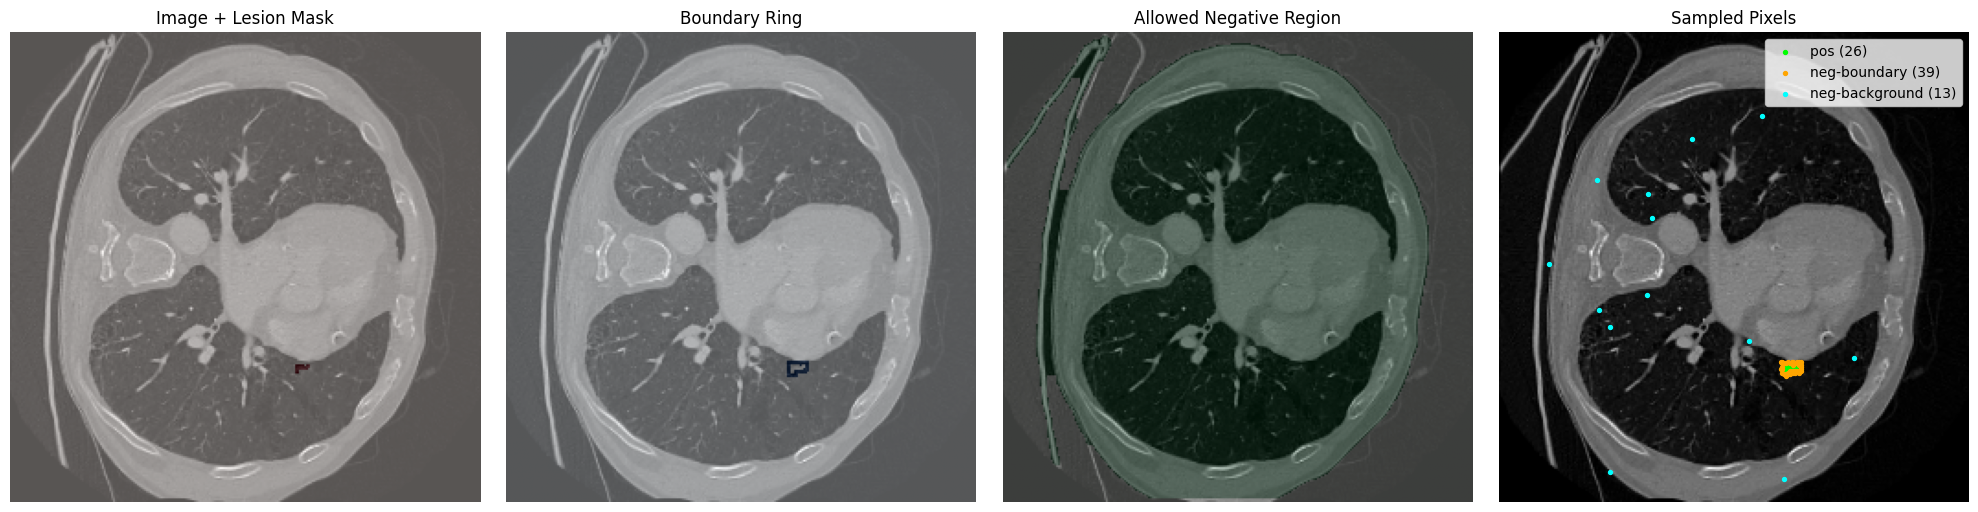

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def _idx_to_yx(indices: torch.Tensor, width: int):
    y = (indices // width).cpu().numpy()
    x = (indices % width).cpu().numpy()
    return y, x

# Grab one batch
images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

# Use current model to get projected embeddings (only shape is needed for sampling indices)
model.eval()
with torch.no_grad():
    features = model.forward_features(images)
    projected = model.forward_projection(features)

# Pick first image in batch that has tumor pixels
chosen = None
for i in range(masks.shape[0]):
    if (masks[i, 0] > 0.5).any():
        chosen = i
        break
if chosen is None:
    raise RuntimeError("No positive-mask image found in this batch. Try another batch.")

mask_i = masks[chosen:chosen+1]  # (1,1,H,W)
img_i = images[chosen, 0].detach().cpu().numpy()
H, W = mask_i.shape[-2], mask_i.shape[-1]

# Constrain negatives to the anatomy-aware region used during training
neg_sampling_mask_i = compute_negative_sampling_mask(
    images[chosen:chosen+1],
    threshold_ratio=0.10,
    dilation_kernel_size=1,
)[0, 0]

# Recreate sampling indices exactly as in sample_pixel_embeddings
boundary_mask = _compute_boundary_mask(mask_i, kernel_size=boundary_kernel_size)[0, 0]
flat_mask = (mask_i.reshape(-1) > 0.5)
flat_boundary = boundary_mask.reshape(-1)
flat_neg_sampling = neg_sampling_mask_i.reshape(-1)

pos_idx = torch.nonzero(flat_mask, as_tuple=False).squeeze(1)
pos_idx = _sample_indices(pos_idx, max_positive_samples)

target_neg = max_negative_samples
if target_neg is None:
    target_neg = max(1, int(np.ceil(pos_idx.numel() * negative_ratio)))

boundary_candidates = flat_boundary & flat_neg_sampling
boundary_idx = torch.nonzero(boundary_candidates, as_tuple=False).squeeze(1)
if boundary_idx.numel() == 0:
    boundary_idx = torch.nonzero(flat_boundary, as_tuple=False).squeeze(1)

bg_candidates = (~flat_mask) & flat_neg_sampling
bg_idx = torch.nonzero(bg_candidates, as_tuple=False).squeeze(1)
if bg_idx.numel() == 0:
    bg_idx = torch.nonzero(~flat_mask, as_tuple=False).squeeze(1)

max_boundary = min(boundary_idx.numel(), int(np.ceil(target_neg * boundary_fraction)))
neg_boundary_idx = _sample_indices(boundary_idx, max_boundary)

remaining = max(0, target_neg - neg_boundary_idx.numel())
if neg_boundary_idx.numel() > 0:
    keep_bg = ~torch.isin(bg_idx, neg_boundary_idx)
    bg_idx = bg_idx[keep_bg]
neg_bg_idx = _sample_indices(bg_idx, remaining)

# Convert to coordinates
pos_y, pos_x = _idx_to_yx(pos_idx, W)
nb_y, nb_x = _idx_to_yx(neg_boundary_idx, W)
ng_y, ng_x = _idx_to_yx(neg_bg_idx, W)

mask_np = mask_i[0, 0].detach().cpu().numpy()
boundary_np = boundary_mask.detach().cpu().numpy().astype(np.float32)
neg_sampling_np = neg_sampling_mask_i.detach().cpu().numpy().astype(np.float32)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_i, cmap="gray")
axes[0].imshow(mask_np, cmap="Reds", alpha=0.35)
axes[0].set_title("Image + Lesion Mask")
axes[0].axis("off")

axes[1].imshow(img_i, cmap="gray")
axes[1].imshow(boundary_np, cmap="Blues", alpha=0.35)
axes[1].set_title("Boundary Ring")
axes[1].axis("off")

axes[2].imshow(img_i, cmap="gray")
axes[2].imshow(neg_sampling_np, cmap="Greens", alpha=0.25)
axes[2].set_title("Allowed Negative Region")
axes[2].axis("off")

axes[3].imshow(img_i, cmap="gray")
axes[3].scatter(pos_x, pos_y, s=8, c="lime", label=f"pos ({len(pos_x)})")
axes[3].scatter(nb_x, nb_y, s=8, c="orange", label=f"neg-boundary ({len(nb_x)})")
axes[3].scatter(ng_x, ng_y, s=8, c="cyan", label=f"neg-background ({len(ng_x)})")
axes[3].set_title("Sampled Pixels")
axes[3].legend(loc="upper right")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Test-set evaluation for the joint model only.
eval_criterion = build_phase2_loss(joint_loss_name)

def evaluate_single_checkpoint(model_name: str, ckpt_path: str, threshold: float):
    if ckpt_path is None or not os.path.exists(ckpt_path):
        raise FileNotFoundError(f'Could not find checkpoint for {model_name}: {ckpt_path}')

    eval_model = UNetContrastive().to(device)
    checkpoint = load_model_checkpoint(eval_model, ckpt_path, strict=True)
    if isinstance(checkpoint, dict) and 'threshold' in checkpoint:
        threshold = float(checkpoint['threshold'])

    eval_model.eval()
    test_loss_sum = 0.0
    test_prob_batches = []
    test_mask_batches = []

    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc=f'Test [Eval:{model_name}]'):
            images = images.to(device)
            masks = masks.to(device)
            features = eval_model.forward_features(images)
            logits = eval_model.forward_classification(features)
            test_loss_sum += float(eval_criterion(logits, masks).item())
            test_prob_batches.append(torch.sigmoid(logits).cpu())
            test_mask_batches.append(masks.cpu())

    test_probs = torch.cat(test_prob_batches, dim=0)
    test_masks = torch.cat(test_mask_batches, dim=0)

    test_probs_np = test_probs.numpy()
    test_masks_np = (test_masks.numpy() > 0.5).astype(np.float32)
    test_preds_np = (test_probs_np >= threshold).astype(np.float32)

    metrics = {
        'checkpoint_path': ckpt_path,
        'threshold_used': float(threshold),
        'test_loss': test_loss_sum / max(1, len(test_loader)),
        'test_global_dice': dice_score_from_binary(test_preds_np, test_masks_np),
        'test_global_iou': iou_score_from_binary(test_preds_np, test_masks_np),
    }
    roc_diag_test = compute_roc_diagnostics(test_probs, test_masks)
    metrics['test_roc_auc'] = roc_diag_test['roc_auc']
    metrics['test_pr_auc'] = roc_diag_test['pr_auc']
    return metrics

joint_ckpt_path = os.path.join(checkpoint_dir, 'contrastive_joint_best.pth')
joint_threshold = 0.5
if 'training_results' in globals():
    joint_info = training_results.get('joint_training', {}).get('joint_best', {})
    joint_ckpt_path = joint_info.get('checkpoint_path', joint_ckpt_path)
    joint_threshold = float(joint_info.get('threshold', 0.5))

if not os.path.exists(joint_ckpt_path):
    raise RuntimeError(
        f'Joint checkpoint not found: {joint_ckpt_path}. '
        'Run joint training first or place the checkpoint in checkpoint_dir.'
    )

test_metrics = evaluate_single_checkpoint('joint_training', joint_ckpt_path, joint_threshold)
test_metrics_by_model = {'joint_training': test_metrics}
best_threshold = float(test_metrics['threshold_used'])

print('\nTest metrics [joint_training]:')
for k, v in test_metrics.items():
    print(f'  {k}: {v}')

test_metrics

/tmp/ipykernel_98/3041510202.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


Test [Eval:joint_training]:   0%|          | 0/167 [00:00<?, ?it/s]


Test metrics [joint_training]:
  checkpoint_path: /kaggle/working/contrastive_outputs_joint_loss_ckpt/checkpoints/contrastive_joint_best.pth
  threshold_used: 0.9
  test_loss: 0.9717677674607602
  test_global_dice: 0.22456040978431702
  test_global_iou: 0.1264815777540207
  test_roc_auc: 0.6001114944968589
  test_pr_auc: 0.14897301050787495


{'checkpoint_path': '/kaggle/working/contrastive_outputs_joint_loss_ckpt/checkpoints/contrastive_joint_best.pth',
 'threshold_used': 0.9,
 'test_loss': 0.9717677674607602,
 'test_global_dice': 0.22456040978431702,
 'test_global_iou': 0.1264815777540207,
 'test_roc_auc': 0.6001114944968589,
 'test_pr_auc': 0.14897301050787495}

In [22]:
# Dice/IoU on only test images that have GT-positive pixels (joint model only).
if 'test_metrics' not in globals():
    joint_ckpt = os.path.join(checkpoint_dir, 'contrastive_joint_best.pth')
    if not os.path.exists(joint_ckpt):
        raise RuntimeError(
            'test_metrics not found and joint checkpoint was not discovered. '
            'Run evaluation first or place contrastive_joint_best.pth in checkpoint_dir.'
        )

    checkpoint = torch.load(joint_ckpt, map_location=device)
    threshold_fallback = float(checkpoint.get('threshold', 0.5)) if isinstance(checkpoint, dict) else 0.5
    test_metrics = {
        'checkpoint_path': joint_ckpt,
        'threshold_used': threshold_fallback,
    }

ckpt_path = test_metrics.get('checkpoint_path')
if ckpt_path is None or not os.path.exists(ckpt_path):
    raise FileNotFoundError(f'Checkpoint not found for joint model: {ckpt_path}')

threshold = float(test_metrics.get('threshold_used', 0.5))
eval_model = UNetContrastive().to(device)
load_model_checkpoint(eval_model, ckpt_path, strict=True)
eval_model.eval()

per_image_dice = []
per_image_iou = []
gt_positive_count = 0
total_images = 0

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='GT-positive metrics [joint_training]'):
        images = images.to(device)
        masks = masks.to(device)

        features = eval_model.forward_features(images)
        logits = eval_model.forward_classification(features)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()

        preds_np = preds.cpu().numpy().astype(np.float32)
        masks_np = (masks.cpu().numpy() > 0.5).astype(np.float32)

        for i in range(preds_np.shape[0]):
            total_images += 1
            gt_i = masks_np[i, 0]
            if np.sum(gt_i) <= 0.0:
                continue
            pr_i = preds_np[i, 0]
            gt_positive_count += 1
            per_image_dice.append(dice_score_from_binary(pr_i, gt_i))
            per_image_iou.append(iou_score_from_binary(pr_i, gt_i))

if gt_positive_count == 0:
    gt_positive_metrics = {
        'model': 'joint_training',
        'threshold_used': threshold,
        'gt_positive_images': 0,
        'total_test_images': total_images,
        'mean_dice_gt_positive': None,
        'mean_iou_gt_positive': None,
        'std_dice_gt_positive': None,
        'std_iou_gt_positive': None,
        'per_image_dice': [],
        'per_image_iou': [],
    }
else:
    gt_positive_metrics = {
        'model': 'joint_training',
        'threshold_used': threshold,
        'gt_positive_images': gt_positive_count,
        'total_test_images': total_images,
        'mean_dice_gt_positive': float(np.mean(per_image_dice)),
        'mean_iou_gt_positive': float(np.mean(per_image_iou)),
        'std_dice_gt_positive': float(np.std(per_image_dice)),
        'std_iou_gt_positive': float(np.std(per_image_iou)),
        'per_image_dice': per_image_dice,
        'per_image_iou': per_image_iou,
    }

print('\nGT-positive-only metrics [joint_training]:')
print(f"  gt_positive_images: {gt_positive_metrics['gt_positive_images']} / {gt_positive_metrics['total_test_images']}")
print(f"  threshold_used: {gt_positive_metrics['threshold_used']:.4f}")
print(f"  mean_dice_gt_positive: {gt_positive_metrics['mean_dice_gt_positive']}")
print(f"  mean_iou_gt_positive: {gt_positive_metrics['mean_iou_gt_positive']}")
print(f"  std_dice_gt_positive: {gt_positive_metrics['std_dice_gt_positive']}")
print(f"  std_iou_gt_positive: {gt_positive_metrics['std_iou_gt_positive']}")

gt_positive_metrics

/tmp/ipykernel_98/3041510202.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


GT-positive metrics [joint_training]:   0%|          | 0/167 [00:00<?, ?it/s]


GT-positive-only metrics [joint_training]:
  gt_positive_images: 101 / 1335
  threshold_used: 0.9000
  mean_dice_gt_positive: 0.2540302857091531
  mean_iou_gt_positive: 0.1978384088465492
  std_dice_gt_positive: 0.3367484167251855
  std_iou_gt_positive: 0.2731167007982761


{'model': 'joint_training',
 'threshold_used': 0.9,
 'gt_positive_images': 101,
 'total_test_images': 1335,
 'mean_dice_gt_positive': 0.2540302857091531,
 'mean_iou_gt_positive': 0.1978384088465492,
 'std_dice_gt_positive': 0.3367484167251855,
 'std_iou_gt_positive': 0.2731167007982761,
 'per_image_dice': [4.9999993478877514e-08,
  4.761904293104635e-08,
  0.6301369667053223,
  0.78899085521698,
  0.8739495873451233,
  0.9103448390960693,
  0.8589743375778198,
  0.8727272748947144,
  0.8799999952316284,
  0.8833333253860474,
  0.7924528121948242,
  0.7594936490058899,
  0.1860465407371521,
  2.3809523241880015e-08,
  2.3809523241880015e-08,
  3.030303119544442e-08,
  2.7027027726944652e-08,
  8.547008434334202e-09,
  3.3333321880490985e-07,
  1.4285711813499802e-07,
  1.2499998547355062e-07,
  2.9411765467557416e-08,
  1.2987013242593548e-08,
  8.849557531220853e-09,
  7.299270077254505e-09,
  6.060606239088884e-09,
  0.2822580635547638,
  0.5545171499252319,
  0.6843501329421997,
  0.

In [23]:
# Save prediction-vs-ground-truth overlays for the joint test model, split by GT availability.
if 'test_metrics' not in globals():
    joint_ckpt = os.path.join(checkpoint_dir, 'contrastive_joint_best.pth')
    if not os.path.exists(joint_ckpt):
        raise RuntimeError(
            'test_metrics not found and joint checkpoint was not discovered. '
            'Run evaluation first or place contrastive_joint_best.pth in checkpoint_dir.'
        )

    checkpoint = torch.load(joint_ckpt, map_location=device)
    threshold_fallback = float(checkpoint.get('threshold', 0.5)) if isinstance(checkpoint, dict) else 0.5
    test_metrics = {
        'checkpoint_path': joint_ckpt,
        'threshold_used': threshold_fallback,
    }

overlay_output_root = os.path.join(output_dir, 'test_overlay_masks_joint')
overlay_with_gt_dir = os.path.join(overlay_output_root, 'with_gt')
overlay_without_gt_dir = os.path.join(overlay_output_root, 'without_gt')
os.makedirs(overlay_with_gt_dir, exist_ok=True)
os.makedirs(overlay_without_gt_dir, exist_ok=True)

overlay_model = UNetContrastive().to(device)
overlay_ckpt_path = test_metrics.get('checkpoint_path')
if overlay_ckpt_path is None or not os.path.exists(overlay_ckpt_path):
    raise FileNotFoundError(f'Could not find checkpoint for overlay export (joint): {overlay_ckpt_path}')

load_model_checkpoint(overlay_model, overlay_ckpt_path, strict=True)
overlay_model.eval()

overlay_threshold = float(test_metrics.get('threshold_used', 0.5))
print(f'\n[joint_training] Using threshold={overlay_threshold:.4f} from {overlay_ckpt_path}')

saved_overlay_count = 0
saved_with_gt_count = 0
saved_without_gt_count = 0

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Saving test overlays [joint_training]'):
        images = images.to(device)
        masks = masks.to(device)

        features = overlay_model.forward_features(images)
        logits = overlay_model.forward_classification(features)
        probs = torch.sigmoid(logits)
        preds = (probs >= overlay_threshold).float()

        images_np = images.cpu().numpy()
        masks_np = (masks.cpu().numpy() > 0.5).astype(np.float32)
        preds_np = preds.cpu().numpy().astype(np.float32)

        for i in range(images_np.shape[0]):
            img = images_np[i, 0]
            gt = masks_np[i, 0]
            pr = preds_np[i, 0]

            img_min = float(np.min(img))
            img_max = float(np.max(img))
            img_norm = (img - img_min) / (img_max - img_min + 1e-8)

            rgb = np.stack([img_norm, img_norm, img_norm], axis=-1)
            alpha = 0.45

            pred_only = (pr > 0.5) & (gt <= 0.5)
            gt_only = (gt > 0.5) & (pr <= 0.5)
            overlap = (pr > 0.5) & (gt > 0.5)

            rgb[pred_only] = (1.0 - alpha) * rgb[pred_only] + alpha * np.array([1.0, 0.0, 0.0], dtype=np.float32)
            rgb[gt_only] = (1.0 - alpha) * rgb[gt_only] + alpha * np.array([0.0, 1.0, 0.0], dtype=np.float32)
            rgb[overlap] = (1.0 - alpha) * rgb[overlap] + alpha * np.array([1.0, 1.0, 0.0], dtype=np.float32)

            has_gt = bool((gt > 0.5).any())
            target_dir = overlay_with_gt_dir if has_gt else overlay_without_gt_dir
            out_name = f'test_{saved_overlay_count:05d}_overlay.png'
            out_path = os.path.join(target_dir, out_name)
            plt.imsave(out_path, np.clip(rgb, 0.0, 1.0))

            saved_overlay_count += 1
            if has_gt:
                saved_with_gt_count += 1
            else:
                saved_without_gt_count += 1

print(f'Saved {saved_overlay_count} overlay images to: {overlay_output_root}')
print(f'  with_gt: {saved_with_gt_count} -> {overlay_with_gt_dir}')
print(f'  without_gt: {saved_without_gt_count} -> {overlay_without_gt_dir}')

overlay_output_root


[joint_training] Using threshold=0.9000 from /kaggle/working/contrastive_outputs_joint_loss_ckpt/checkpoints/contrastive_joint_best.pth


/tmp/ipykernel_98/3041510202.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


Saving test overlays [joint_training]:   0%|          | 0/167 [00:00<?, ?it/s]

Saved 1335 overlay images to: /kaggle/working/contrastive_outputs_joint_loss_ckpt/test_overlay_masks_joint
  with_gt: 101 -> /kaggle/working/contrastive_outputs_joint_loss_ckpt/test_overlay_masks_joint/with_gt
  without_gt: 1234 -> /kaggle/working/contrastive_outputs_joint_loss_ckpt/test_overlay_masks_joint/without_gt


'/kaggle/working/contrastive_outputs_joint_loss_ckpt/test_overlay_masks_joint'

In [24]:
# Create a Kaggle-downloadable zip for saved joint overlay masks.
import zipfile

overlay_dir_for_zip = overlay_output_root if 'overlay_output_root' in globals() else os.path.join(output_dir, 'test_overlay_masks_joint')
if not os.path.isdir(overlay_dir_for_zip):
    raise FileNotFoundError(f'Overlay directory not found: {overlay_dir_for_zip}')

zip_output_path = '/kaggle/working/test_overlay_masks_joint.zip'
with zipfile.ZipFile(zip_output_path, mode='w', compression=zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(overlay_dir_for_zip):
        for fname in files:
            src_path = os.path.join(root, fname)
            arcname = os.path.relpath(src_path, overlay_dir_for_zip)
            zf.write(src_path, arcname=arcname)

zip_size_mb = os.path.getsize(zip_output_path) / (1024 * 1024)
print(f'Created zip: {zip_output_path}')
print(f'Zip size: {zip_size_mb:.2f} MB')
zip_output_path

Created zip: /kaggle/working/test_overlay_masks_joint.zip
Zip size: 80.62 MB


'/kaggle/working/test_overlay_masks_joint.zip'

## Training Curves: Joint Model
Use this section after training to visualize joint train/validation loss and Dice trends.

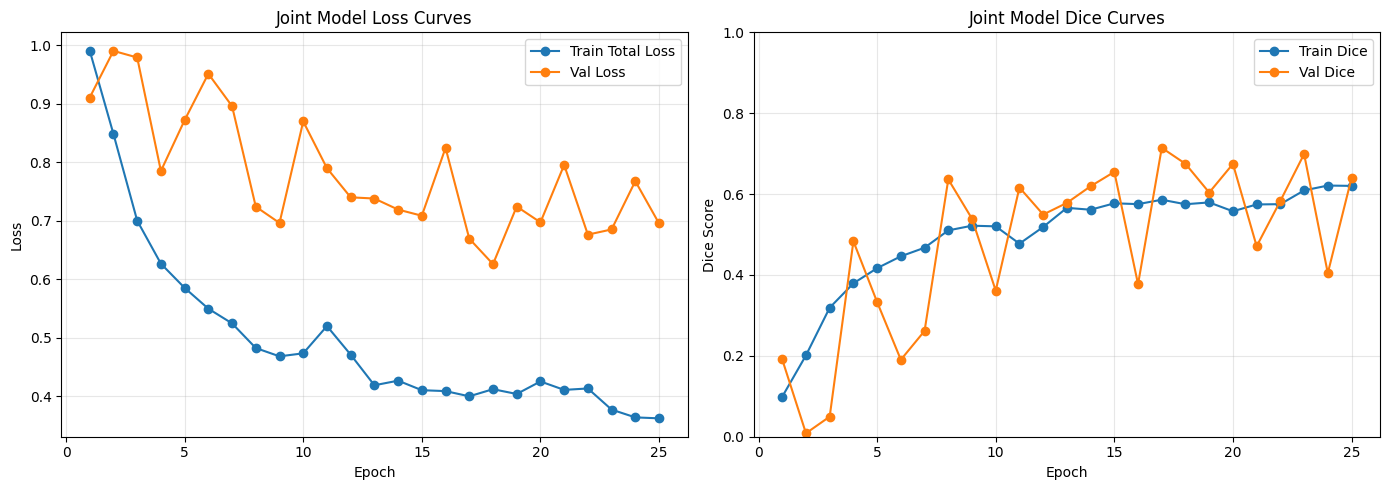

In [25]:
# Plot train/val loss and Dice curves for the joint model.
if 'training_results' not in globals():
    raise RuntimeError('training_results not found. Run the joint training cell first.')

joint_history = training_results.get('joint_training', {}).get('joint_history', {})
required_joint = ['train_total_loss', 'val_loss', 'train_dice', 'val_global_dice']
missing_joint = [k for k in required_joint if k not in joint_history]
if missing_joint:
    raise KeyError(f'Missing keys in joint_history: {missing_joint}')

joint_epochs = np.arange(1, len(joint_history['train_total_loss']) + 1)
if joint_epochs.size == 0:
    raise RuntimeError('Joint history is empty. Run full joint training first.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(joint_epochs, joint_history['train_total_loss'], marker='o', label='Train Total Loss')
axes[0].plot(joint_epochs, joint_history['val_loss'], marker='o', label='Val Loss')
axes[0].set_title('Joint Model Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(joint_epochs, joint_history['train_dice'], marker='o', label='Train Dice')
axes[1].plot(joint_epochs, joint_history['val_global_dice'], marker='o', label='Val Dice')
axes[1].set_title('Joint Model Dice Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()